# Telescopic OTA
## Notebook Author: Rosnel Leyva-Cortes
This notebook is an example for how to design a telescopic operational transconductance amplifier from python description, to netlist, to layout using the SKY130 process technology.

Note for future implementations: There is a notably more reliable layout generation when using X-cells in PySpice compared to just using a standard M# formatting for transistors. I don't have much time to figure out why but this is notable behavior to explore further.

# Checking Imports

In [1]:
import os 
import PySpice.Spice.Simulation
import subprocess
import gdstk
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np
import time
import tracemalloc
import subprocess

from PySpice.Spice.Netlist import Circuit
from PySpice.Unit import *
from pathlib import Path

PySpice.Spice.Simulation.CircuitSimulator.DEFAULT_SIMULATOR = 'ngspice-shared'

# Haven't figured out how to port these paths onto system calls, but good to keep track of
ALIGN_PDK_DIR = './ALIGN-public/pdks/SKY130_PDK/'
ALIGN_NET_DIR = './ALIGN_WORK_DIR/'
GDS_OUTPUT_DIR = 'ALIGN_WORK_DIR/GDS_OUT'

# Function and Class Definition

In [2]:
#pyspice to align port 
def export_circuit_to_align(circuit, align_dir='ALIGN_WORK_DIR', cell_name='my_circuit'):
    """
    Exports a PySpice circuit to a SPICE netlist compatible with ALIGN.

    Parameters:
    - circuit: PySpice Circuit object
    - align_dir: str, path to ALIGN working directory
    - cell_name: str, name of the circuit (also used as subckt name and folder name)
    """
    #from PySpice.Spice.Netlist import Circuit

    if not isinstance(circuit, Circuit):
        raise ValueError("Expected a PySpice Circuit object.")

    # Create target directory
    cell_dir = Path(align_dir) / cell_name
    cell_dir.mkdir(parents=True, exist_ok=True)

    # Format the netlist string
    netlist_lines = str(circuit).splitlines()

    # Remove .include or .lib lines (ALIGN doesn't need models here)
    netlist_lines = [line for line in netlist_lines if not line.strip().lower().startswith(('.include', '.lib', '.param', '.control'))]

    # Ensure netlist is wrapped in a .subckt block if not already
    has_subckt = any(line.lower().startswith('.subckt') for line in netlist_lines)
    if not has_subckt:
        # Collect all nodes involved (rough heuristic)
        nodes = set()
        for line in netlist_lines:
            tokens = line.split()
            if tokens and tokens[0][0].upper() in 'MRCLX':
                nodes.update(tokens[1:-1])
        #this line of collecting the ports needs to be fixed. I forgot that this includes all intermediary nodes and not ports 
        ports = ' '.join(sorted(nodes - {'vdd', 'vss', 'gnd'}))
        netlist_lines.insert(0, f'.subckt {cell_name} {ports}')
        netlist_lines.append(f'.ends {cell_name}')

    # Write to file
    netlist_path = cell_dir / f'{cell_name}.sp'
    with open(netlist_path, 'w') as f:
        f.write('\n'.join(netlist_lines))

    print(f" 😆 Netlist exported for ALIGN: {netlist_path}")

In [3]:
def make_current_mirror_ota(w, l):
    circuit = Circuit('Current Mirror OTA')

    # Sky130 model include
    circuit.lib('pySpiceLibrary/skywater-pdk/libraries/sky130_fd_pr/latest/models/sky130.lib.spice', 'tt')

    # Nodes: vss, vdd, vout, vinn, vinp, id, source

    # M5: tail current source mirror
    circuit.X('M4', 'sky130_fd_pr__nfet_01v8', 'tail', 'bias4', 'vss', 'vss', w=w, l=l)

    # M3/M0: differential pair
    circuit.X('M3', 'sky130_fd_pr__nfet_01v8', 'n7', 'vinn', 'tail', 'vss', w=w, l=l)
    circuit.X('M0', 'sky130_fd_pr__nfet_01v8', 'n2', 'vinp', 'tail', 'vss', w=w, l=l)

    # PMOS current mirror M2/M6 and M1/M7
    circuit.X('M2', 'sky130_fd_pr__pfet_01v8', 'n2', 'n2', 'vdd', 'vdd', w=w, l=l)
    circuit.X('M5', 'sky130_fd_pr__pfet_01v8', 'vout', 'n2', 'vdd', 'vdd', w=w, l=l)
    circuit.X('M1', 'sky130_fd_pr__pfet_01v8', 'n8', 'n7', 'vdd', 'vdd', w=w, l=l)
    circuit.X('M6', 'sky130_fd_pr__pfet_01v8', 'n7', 'n7', 'vdd', 'vdd', w=w, l=l)

    # Current mirrors (M8/M9)
    circuit.X('M7', 'sky130_fd_pr__nfet_01v8', 'n8', 'n8', 'vss', 'vss', w=w, l=l)
    circuit.X('M8', 'sky130_fd_pr__nfet_01v8', 'vout', 'n8', 'vss', 'vss', w=w, l=l)

    return circuit

# Circuit Definition

In [4]:
ota = make_current_mirror_ota(w=10.5e-7, l=150e-9)

In [5]:
print(ota)

.title Current Mirror OTA
.lib /PIACC/pySpiceLibrary/skywater-pdk/libraries/sky130_fd_pr/latest/models/sky130.lib.spice tt
XM4 tail bias4 vss vss sky130_fd_pr__nfet_01v8 l=1.5e-07 w=1.05e-06
XM3 n7 vinn tail vss sky130_fd_pr__nfet_01v8 l=1.5e-07 w=1.05e-06
XM0 n2 vinp tail vss sky130_fd_pr__nfet_01v8 l=1.5e-07 w=1.05e-06
XM2 n2 n2 vdd vdd sky130_fd_pr__pfet_01v8 l=1.5e-07 w=1.05e-06
XM5 vout n2 vdd vdd sky130_fd_pr__pfet_01v8 l=1.5e-07 w=1.05e-06
XM1 n8 n7 vdd vdd sky130_fd_pr__pfet_01v8 l=1.5e-07 w=1.05e-06
XM6 n7 n7 vdd vdd sky130_fd_pr__pfet_01v8 l=1.5e-07 w=1.05e-06
XM7 n8 n8 vss vss sky130_fd_pr__nfet_01v8 l=1.5e-07 w=1.05e-06
XM8 vout n8 vss vss sky130_fd_pr__nfet_01v8 l=1.5e-07 w=1.05e-06



# Layout Generation

In [6]:
export_circuit_to_align(ota, align_dir=ALIGN_NET_DIR, cell_name='currentMirror_OTA_example')

 😆 Netlist exported for ALIGN: ALIGN_WORK_DIR/currentMirror_OTA_example/currentMirror_OTA_example.sp


In [7]:
!schematic2layout.py './ALIGN_WORK_DIR/currentMirror_OTA_example' -p '/ALIGN-public/pdks/SKY130_PDK/' -w './ALIGN_WORK_DIR/GDS_OUT'

align.main INFO : Reading netlist: /PIACC/ALIGN_WORK_DIR/currentMirror_OTA_example/currentMirror_OTA_example.sp subckt=CURRENTMIRROR_OTA_EXAMPLE, flat=0
align.compiler.compiler INFO : Starting topology identification...
align.compiler.compiler INFO : Power and ground nets not found. Power grid will not be constructed.
align.compiler.compiler INFO : Completed topology identification.
align.cell_fabric.drc ERROR : Found errors: DRC 7
align.cell_fabric.drc ERROR : Found errors: DRC 7
align.cell_fabric.drc ERROR : Found errors: DRC 2
align.pnr.main INFO : Running Place & Route for CURRENTMIRROR_OTA_EXAMPLE
align.pnr.build_pnr_model INFO : Reading contraint json file CURRENTMIRROR_OTA_EXAMPLE.pnr.const.json
align.pnr.build_pnr_model INFO : Reading contraint json file CURRENTMIRROR_OTA_EXAMPLE.pnr.const.json
align.pnr.placer INFO : Starting bottom-up placement on CURRENTMIRROR_OTA_EXAMPLE 0
PnR.placer.Placer.PlacementCoreAspectRatio_ILP INFO : Required 1 perturbations to generate a feasible 

# Output GDS should look like this 

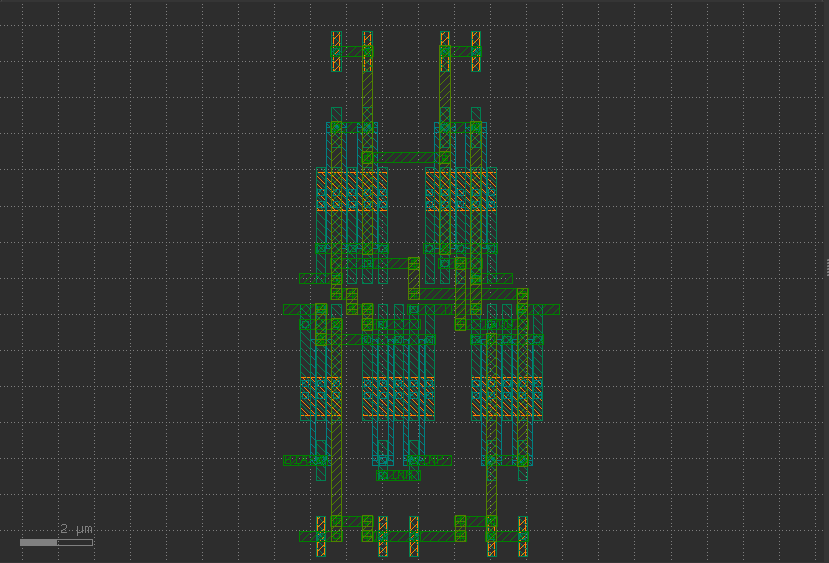

# Metrics and Data Collection

In [4]:
def run_align_with_metrics(netlist_path, align_command):
    """
    Runs ALIGN via shell command and tracks runtime + memory usage.
    
    Args:
        netlist_path (str): Path to netlist file (.sp)
        align_command (list): e.g., ['python3', '-m', 'align.main', '-c', 'my_design_dir']
    Returns:
        dict with runtime, memory, and num_devices
    """
    # Start measuring
    tracemalloc.start()
    start_time = time.perf_counter()

    # Run ALIGN shell command
    result = subprocess.run(align_command, stdout=subprocess.PIPE, stderr=subprocess.PIPE, text=True)

    end_time = time.perf_counter()
    current, peak = tracemalloc.get_traced_memory()
    tracemalloc.stop()

    # Check for errors
    if result.returncode != 0:
        print("ALIGN failed:")
        print(result.stderr)

    # Count devices from netlist
    num_devices = count_devices_from_netlist(netlist_path)

    return {
        'runtime_sec': end_time - start_time,
        'memory_MB': peak / (1024 ** 2),
        'num_devices': num_devices,
        'stdout': result.stdout
    }

In [5]:
def count_devices_from_netlist(netlist_path):
    count = 0
    with open(netlist_path, 'r') as file:
        for line in file:
            line = line.strip().lower()
            if line.startswith('m') or line.startswith('x'):
                count += 1
    return count

In [6]:
metrics = run_align_with_metrics(
    netlist_path='./ALIGN_WORK_DIR/currentMirror_OTA_example/currentMirror_OTA_example.sp',
    align_command=[
        'schematic2layout.py',
        './ALIGN_WORK_DIR/currentMirror_OTA_example',
        '-p', '/ALIGN-public/pdks/SKY130_PDK/',
        '-w', './ALIGN_WORK_DIR/GDS_OUT'
    ]
)

print(metrics)

{'runtime_sec': 32.158741270000064, 'memory_MB': 0.060669898986816406, 'num_devices': 9, 'stdout': '\x1balign.main INFO : Reading netlist: /PIACC/ALIGN_WORK_DIR/currentMirror_OTA_example/currentMirror_OTA_example.sp subckt=CURRENTMIRROR_OTA_EXAMPLE, flat=0\x1b\n\x1balign.compiler.compiler INFO : Starting topology identification...\x1b\n\x1balign.compiler.compiler INFO : Power and ground nets not found. Power grid will not be constructed.\x1b\n\x1balign.compiler.compiler INFO : Completed topology identification.\x1b\n\x1balign.cell_fabric.drc ERROR : Found errors: DRC 7\x1b\n\x1balign.cell_fabric.drc ERROR : Found errors: DRC 7\x1b\n\x1balign.cell_fabric.drc ERROR : Found errors: DRC 2\x1b\n\x1balign.pnr.main INFO : Running Place & Route for CURRENTMIRROR_OTA_EXAMPLE\x1b\n\x1balign.pnr.build_pnr_model INFO : Reading contraint json file CURRENTMIRROR_OTA_EXAMPLE.pnr.const.json\x1b\n\x1balign.pnr.build_pnr_model INFO : Reading contraint json file CURRENTMIRROR_OTA_EXAMPLE.pnr.const.json\x